In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33645")
client

<Client: 'tcp://127.0.0.1:33645' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [7]:
grav = 9.807
ddir = "/storage/tartar/takaya/swot/"

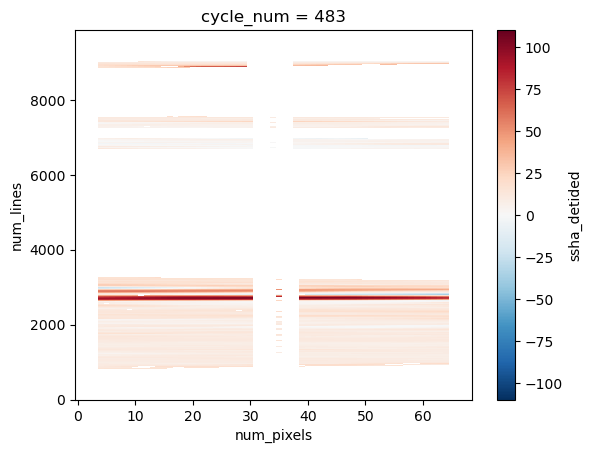

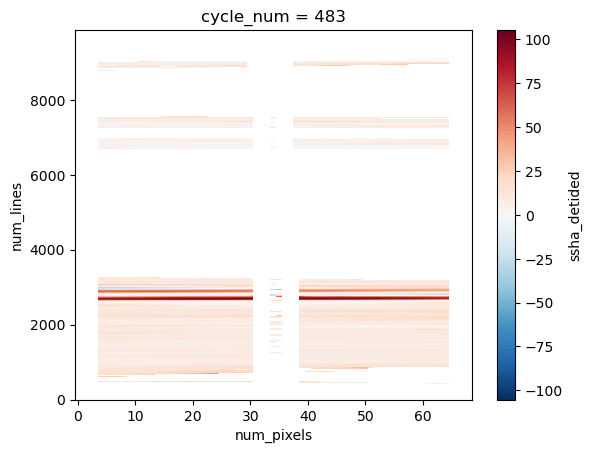

<xarray.Dataset> Size: 582MB
Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray> <xarray.DataArray 'ssha_detided' (cycle_num: 96, num_lines: 9860, num_pixels: 69)> Size: 523MB
dask.array<rechunk-p2p, shape=(96, 9860, 69), dtype=float64, chunksize=(1, 9860, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num  (cycle_num) int64 768B 483 484 485 486 487 ... 575 576 577 578
    latitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
    longitude

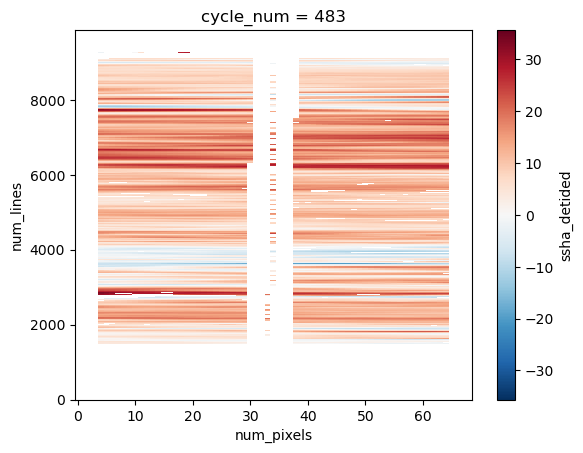

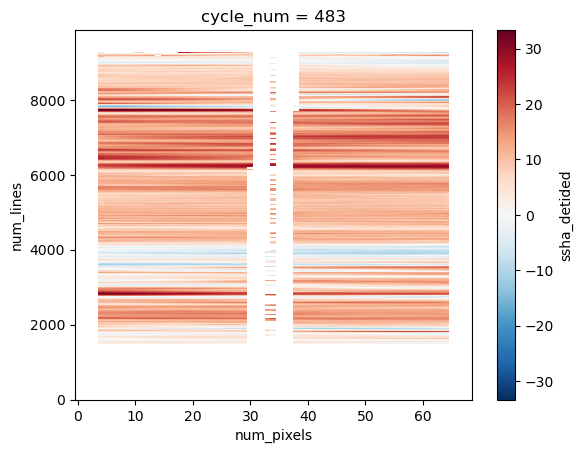

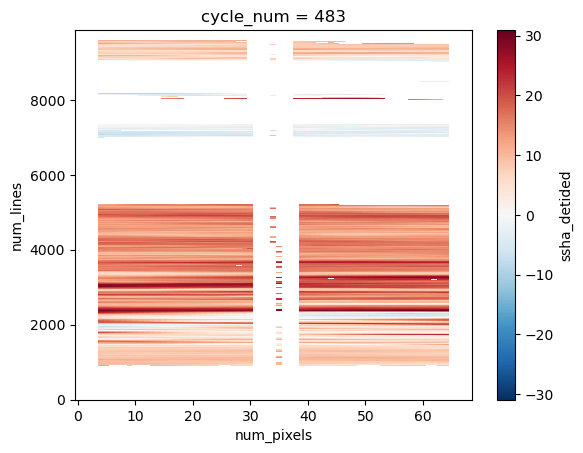

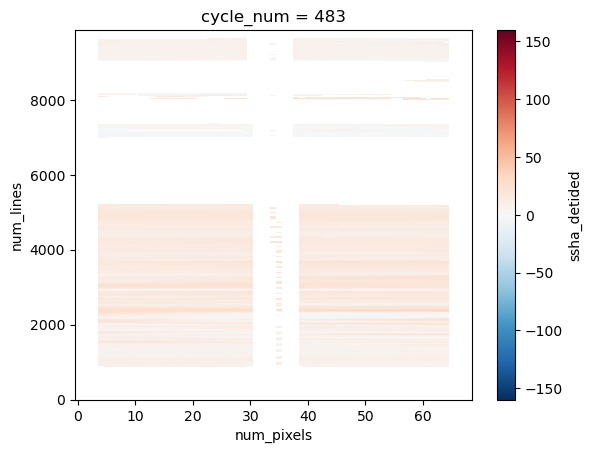

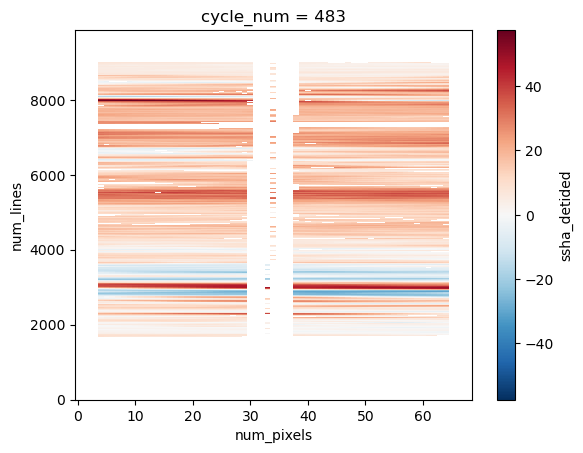

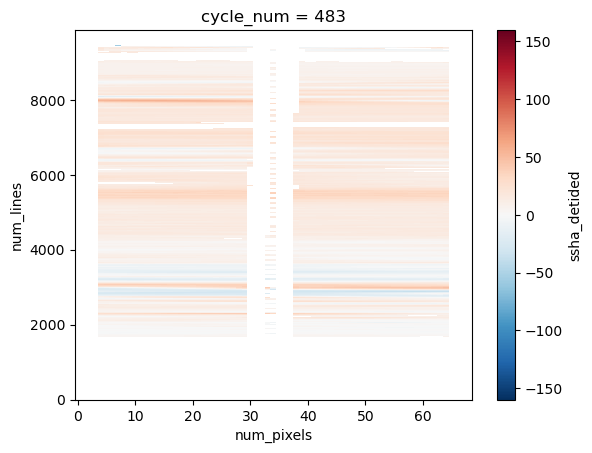

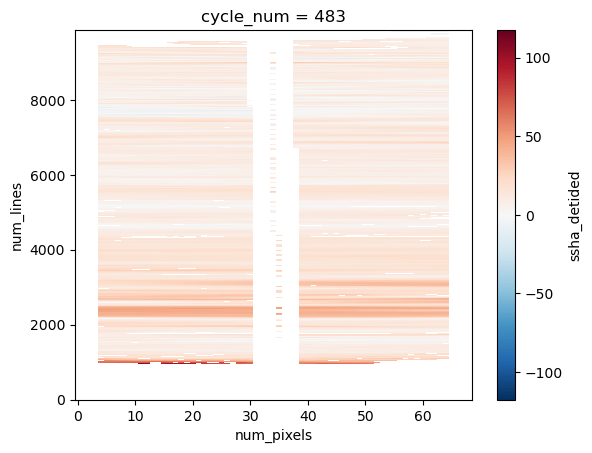

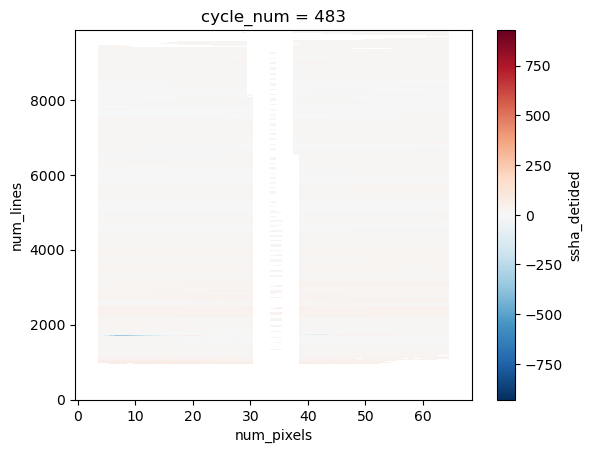

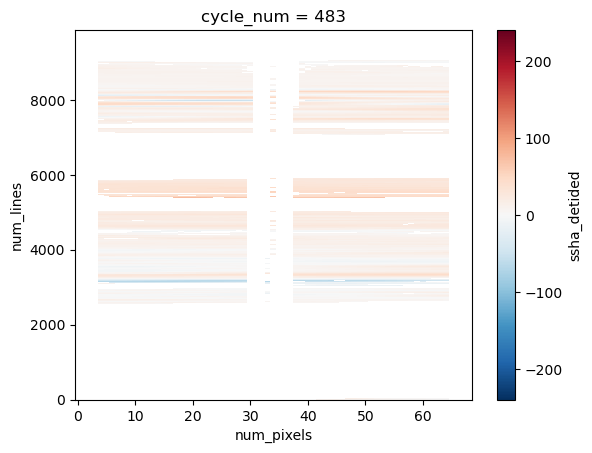

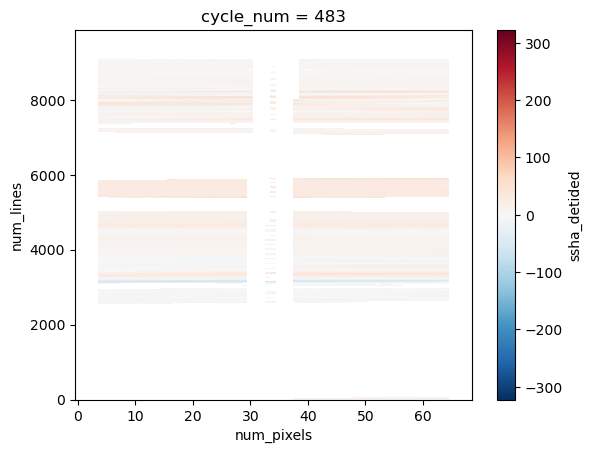

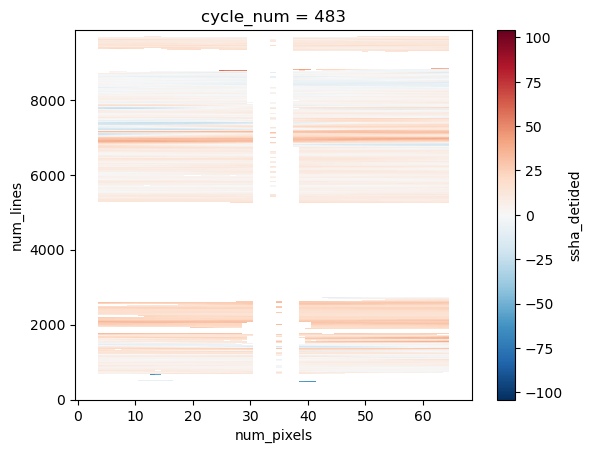

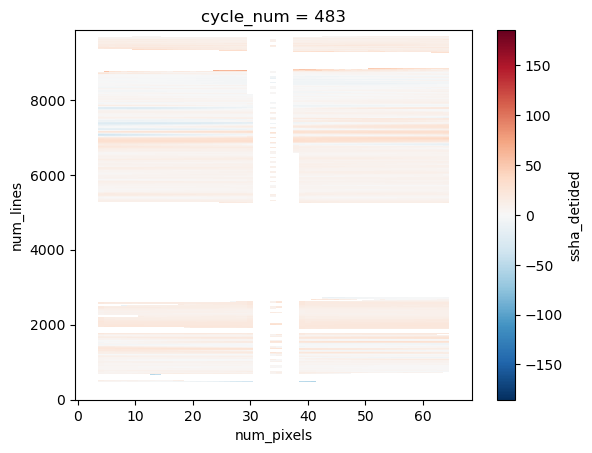

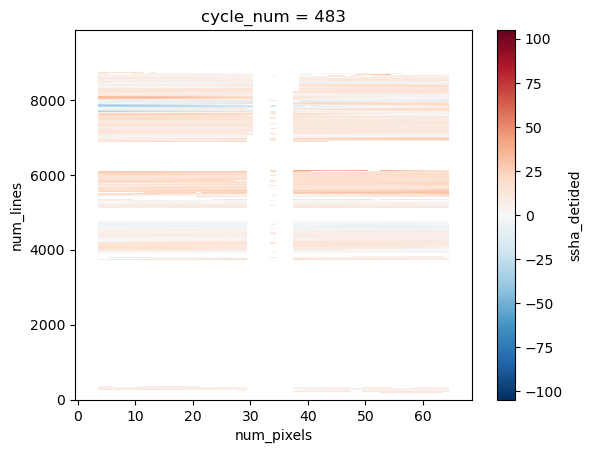

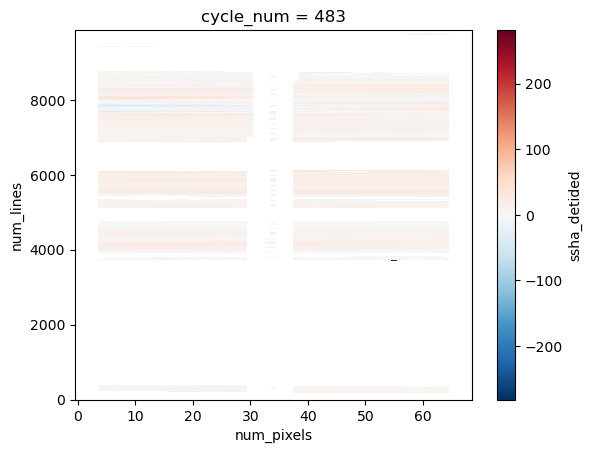

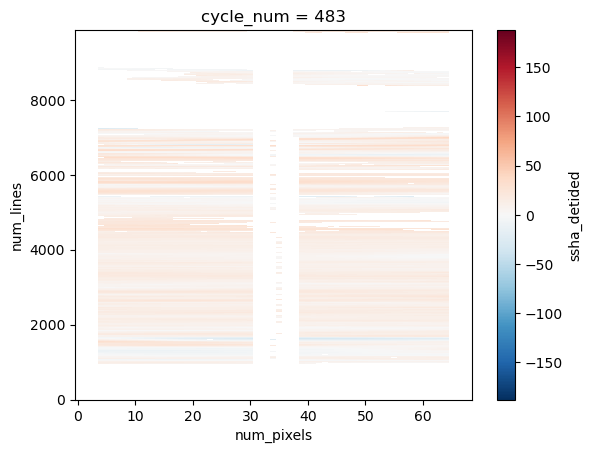

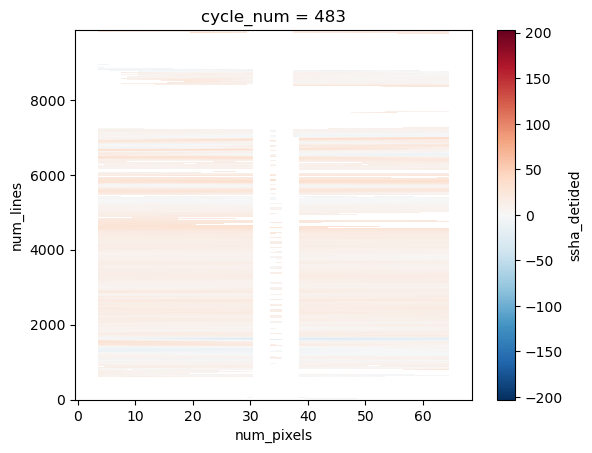

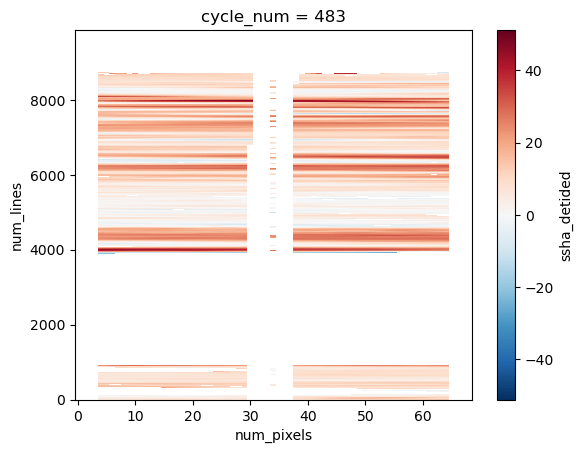

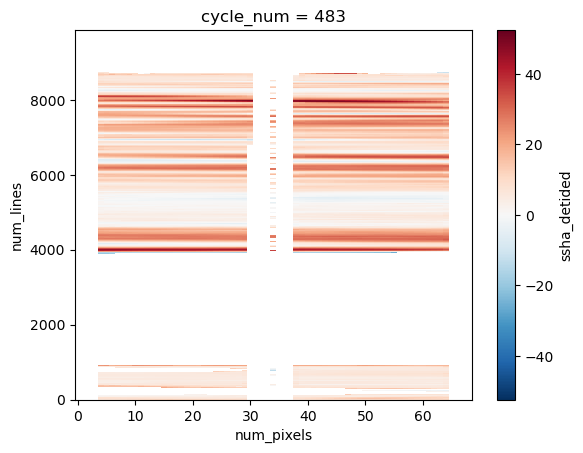

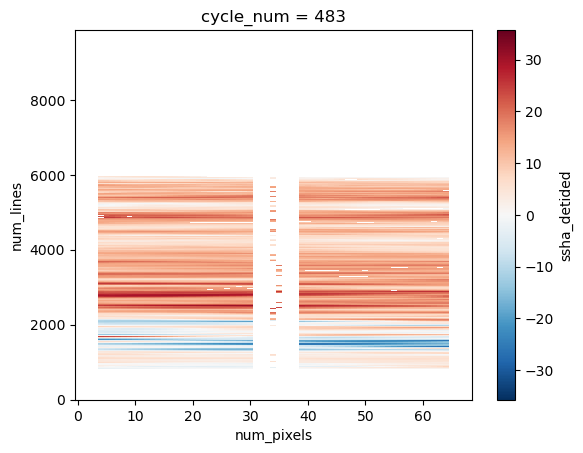

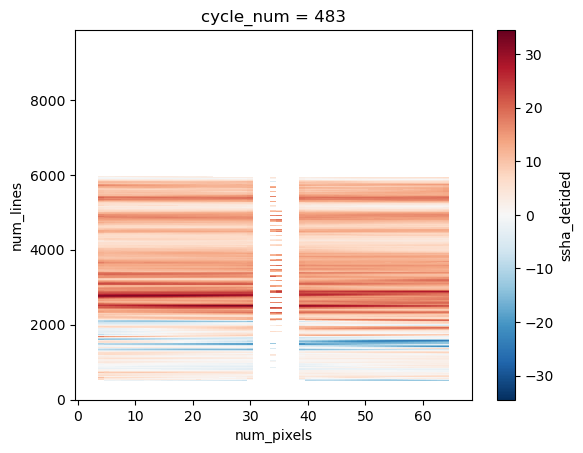

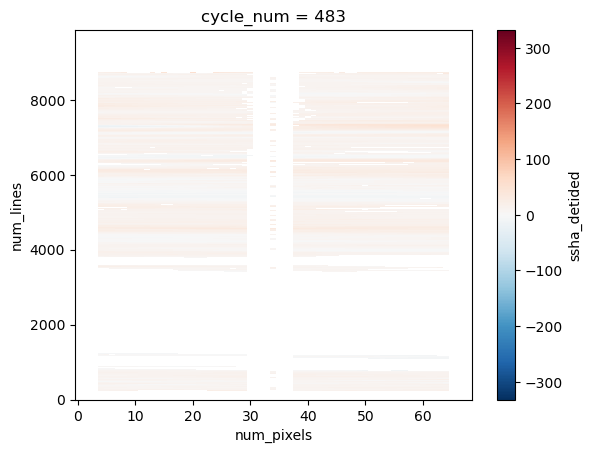

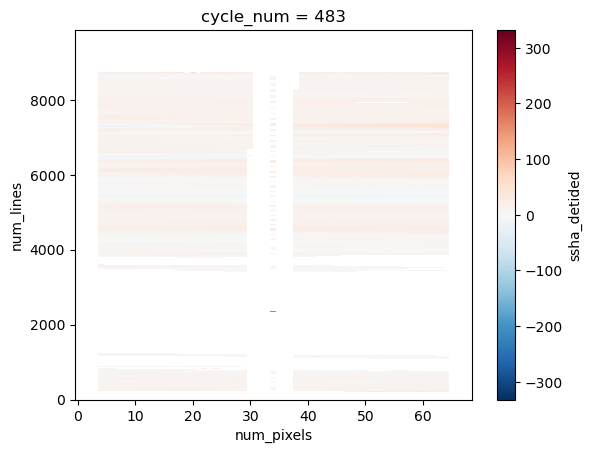

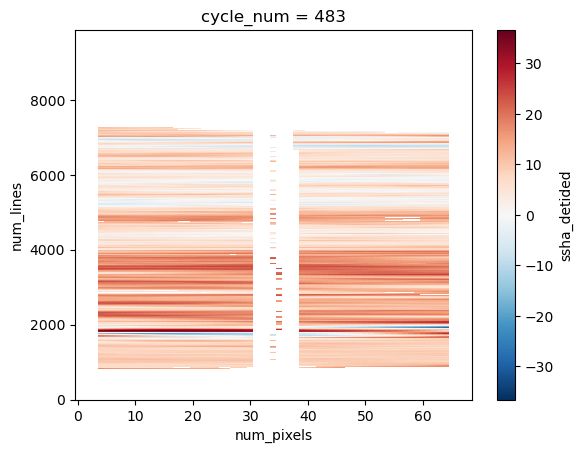

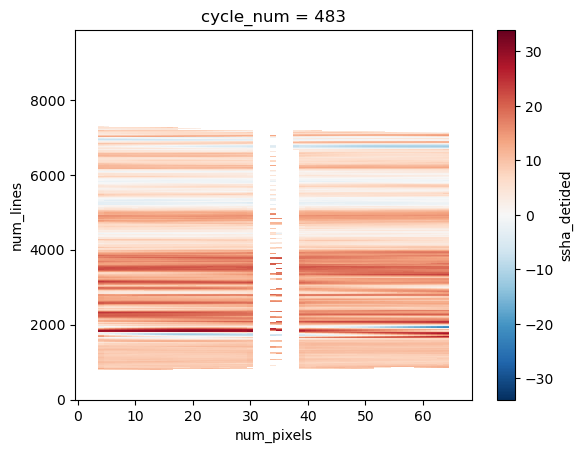

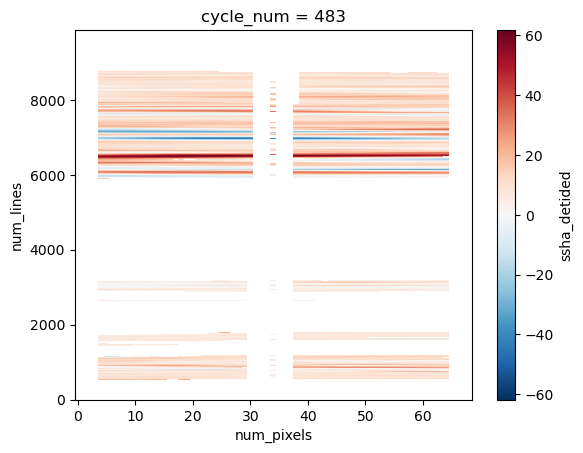

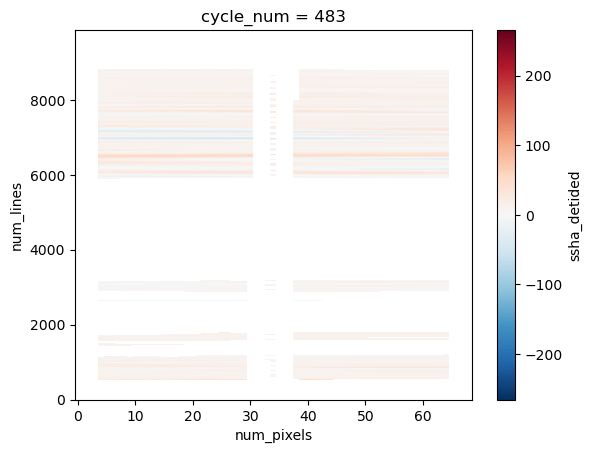

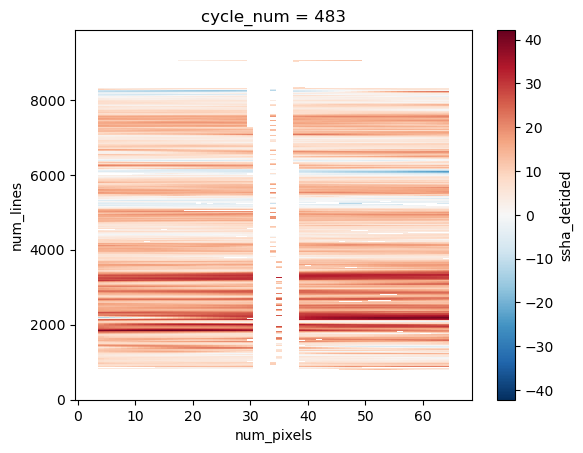

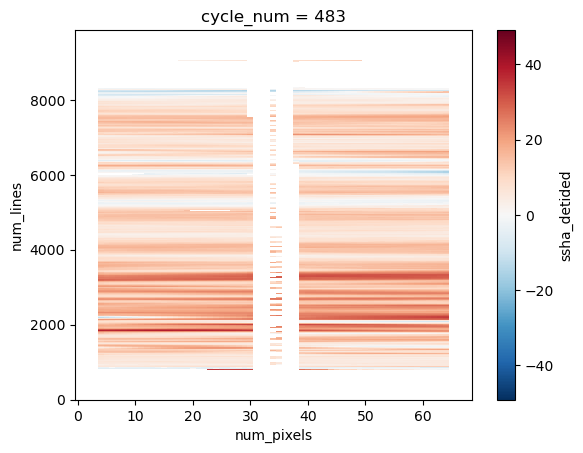

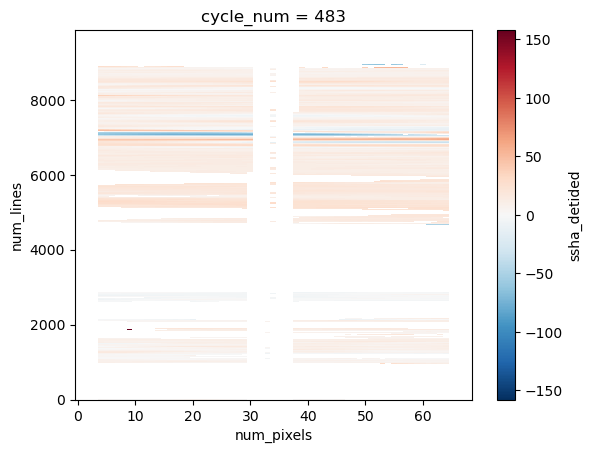

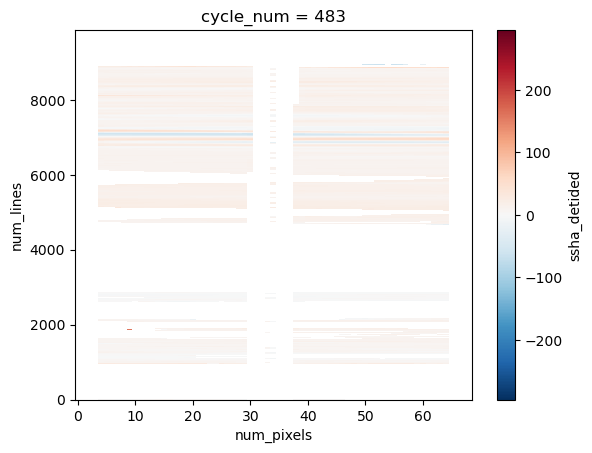

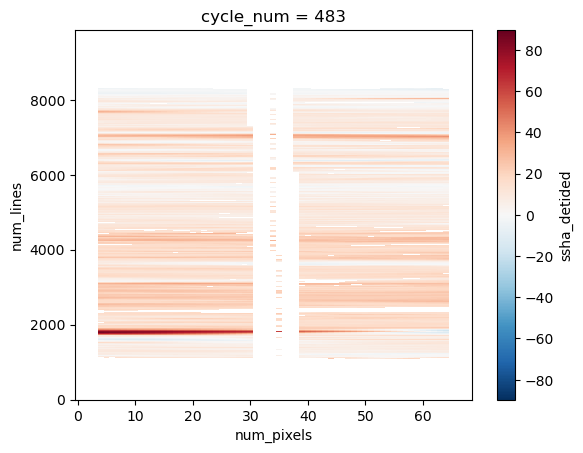

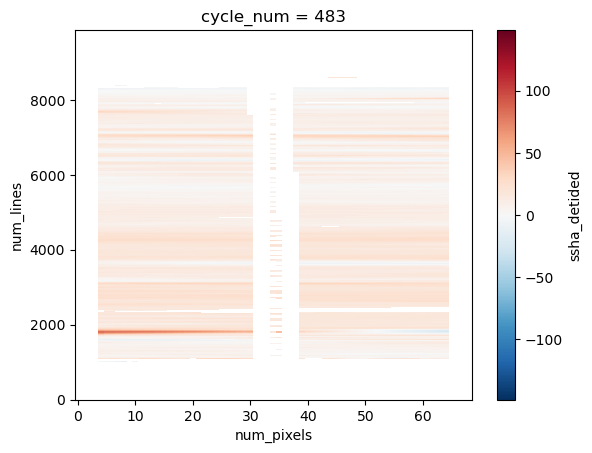

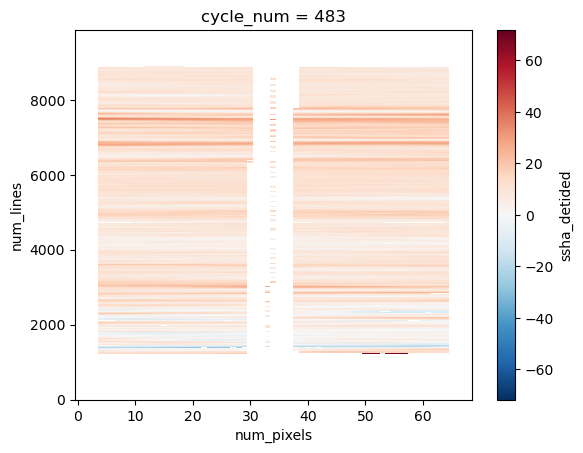

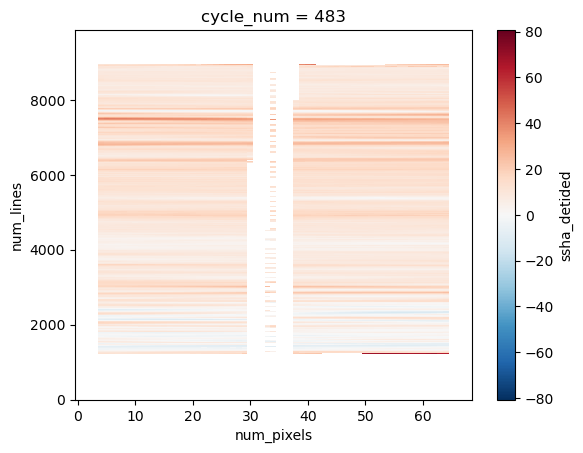

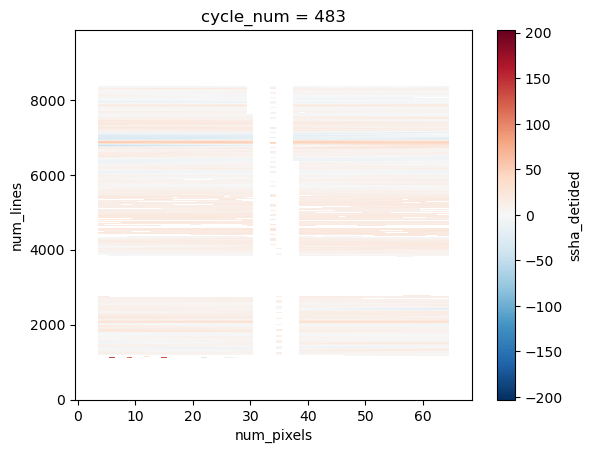

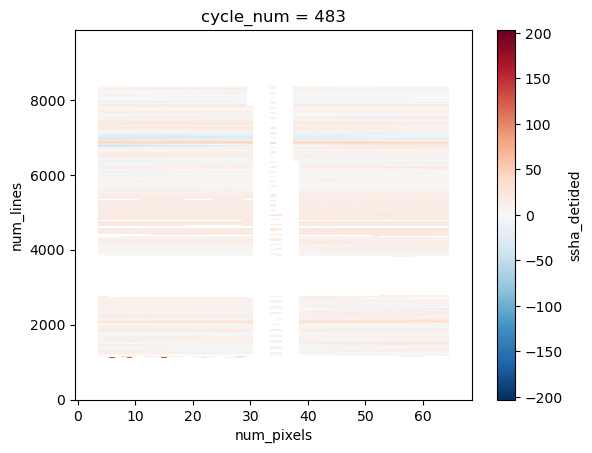

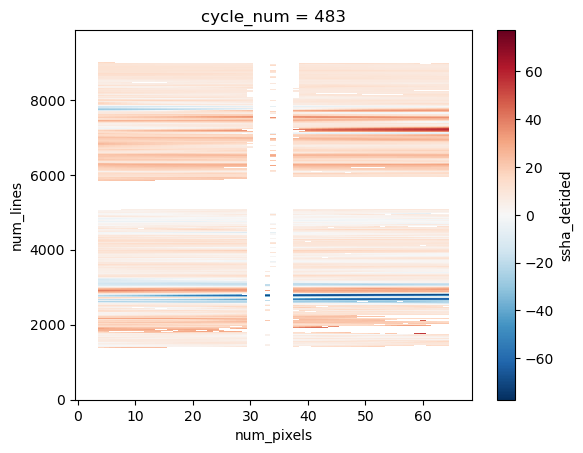

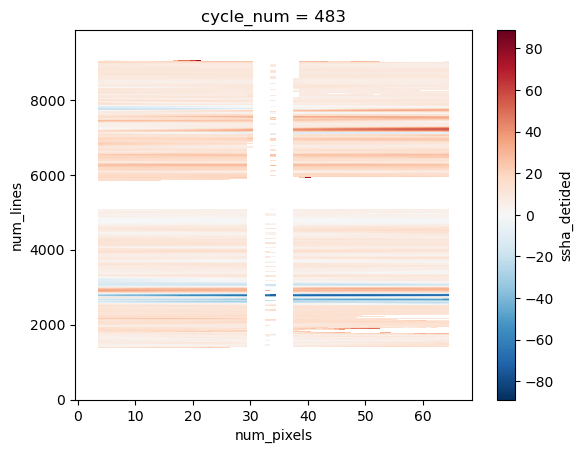

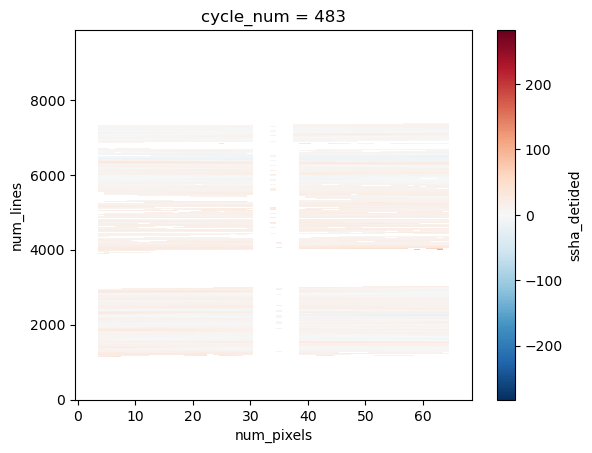

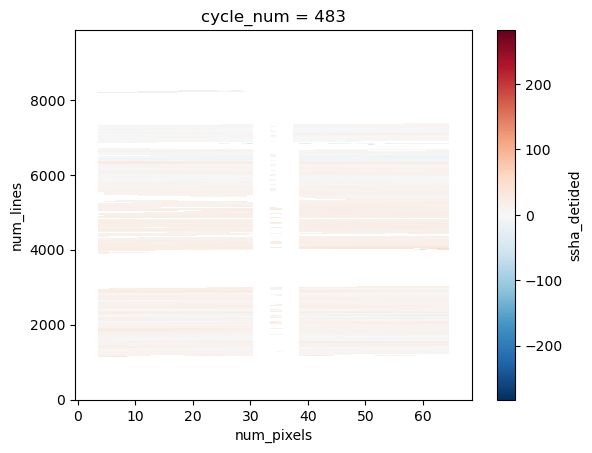

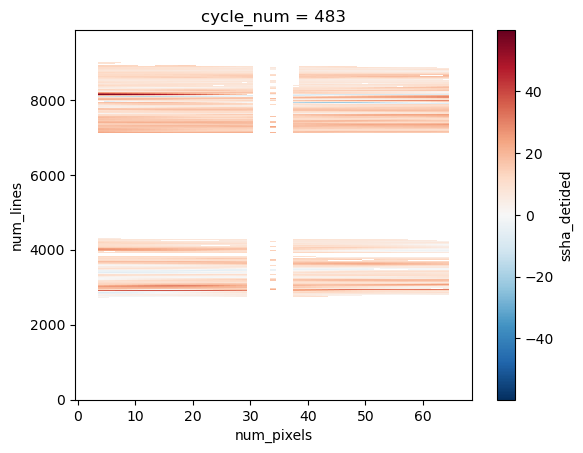

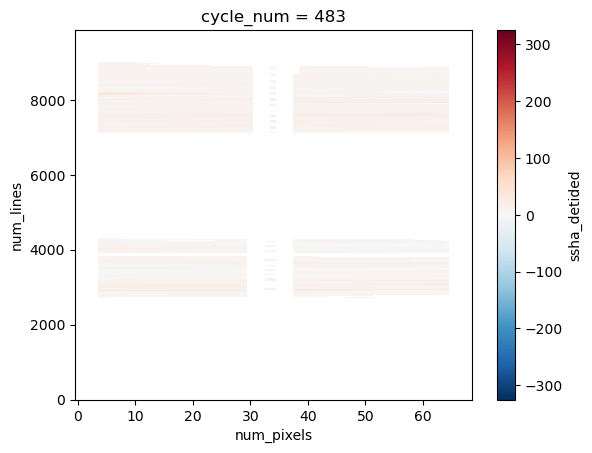

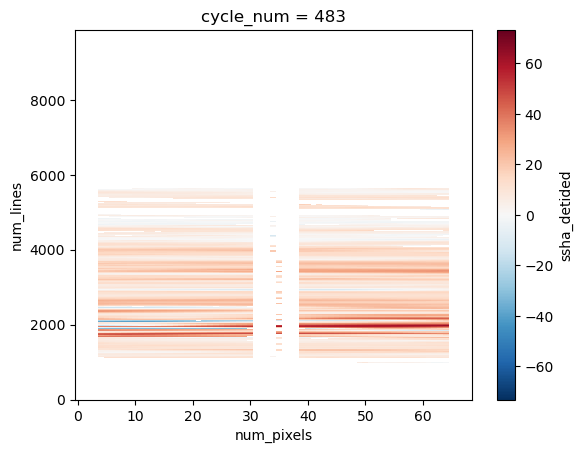

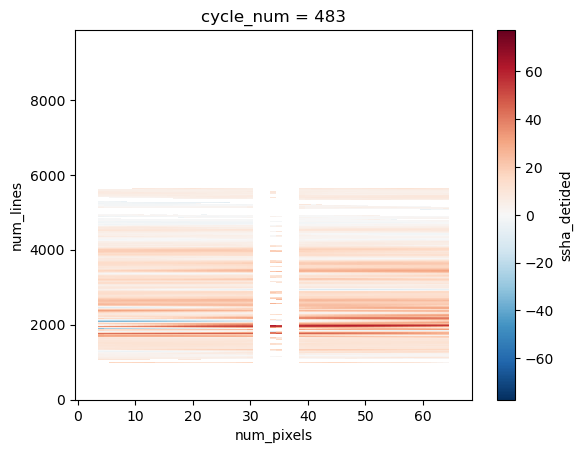

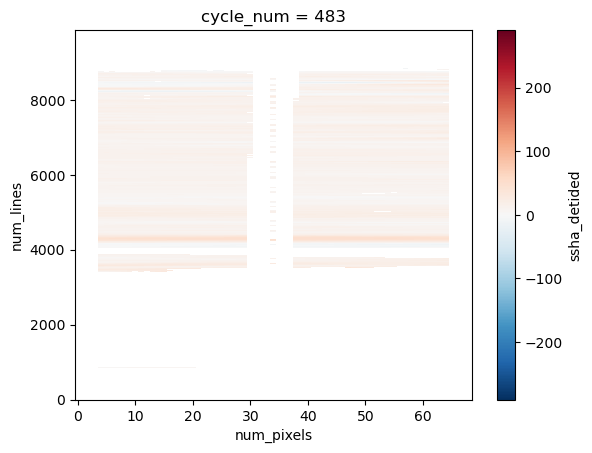

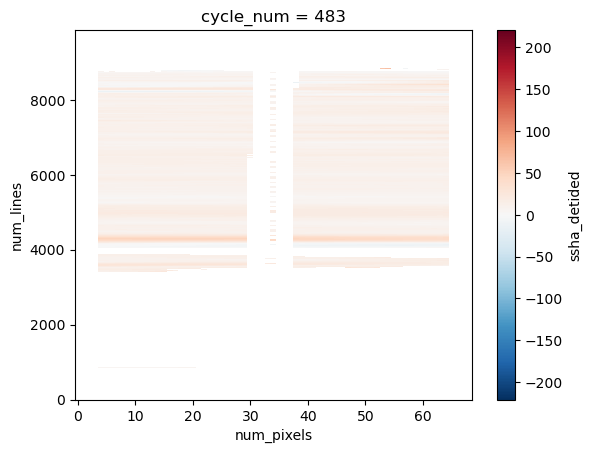

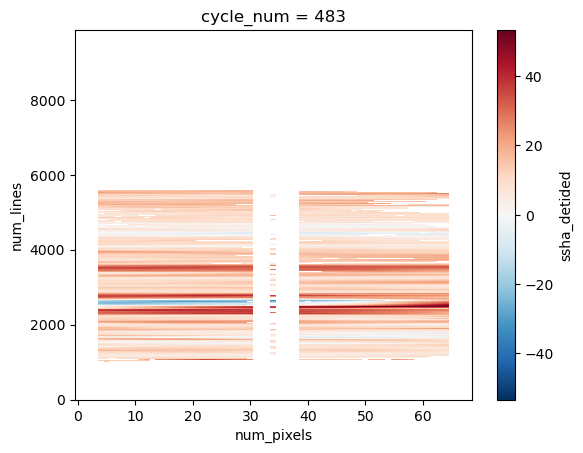

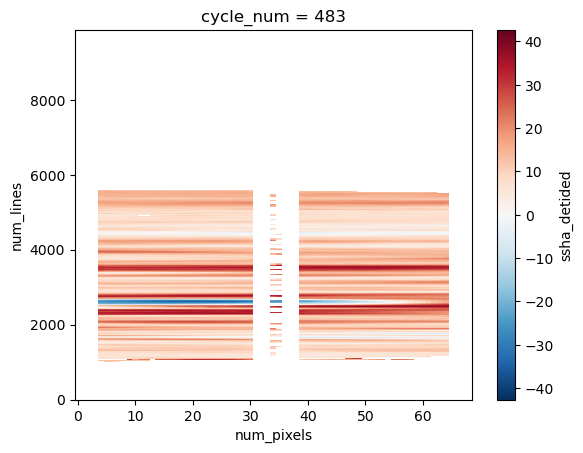

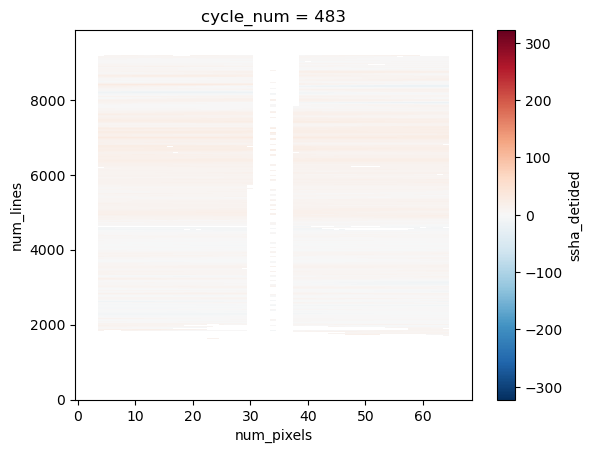

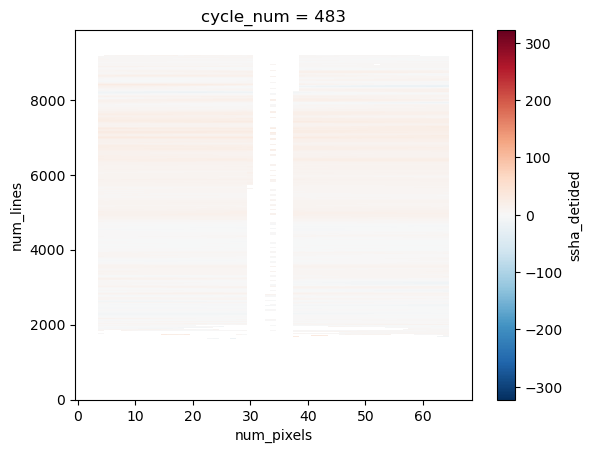

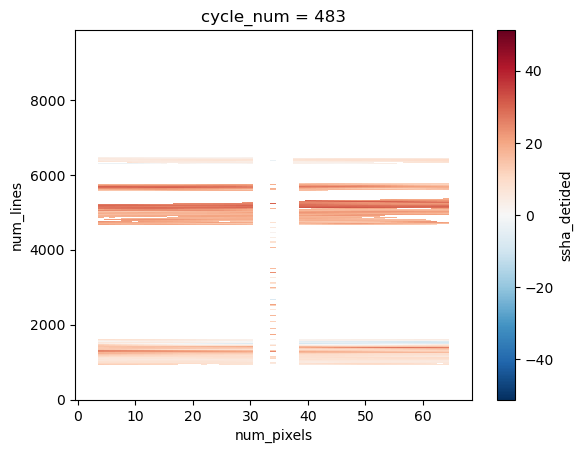

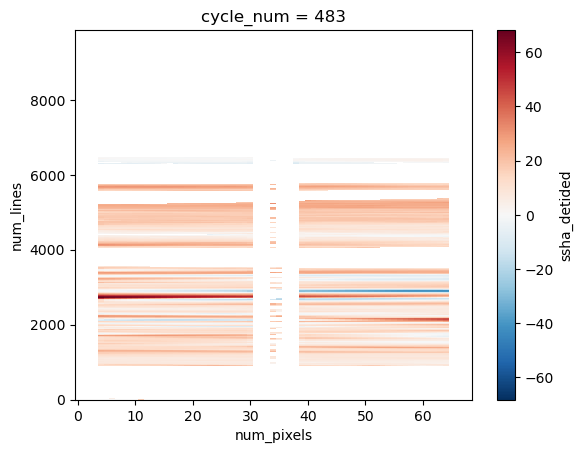

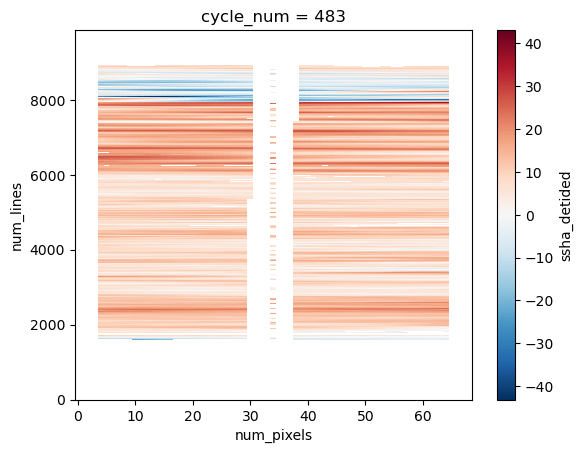

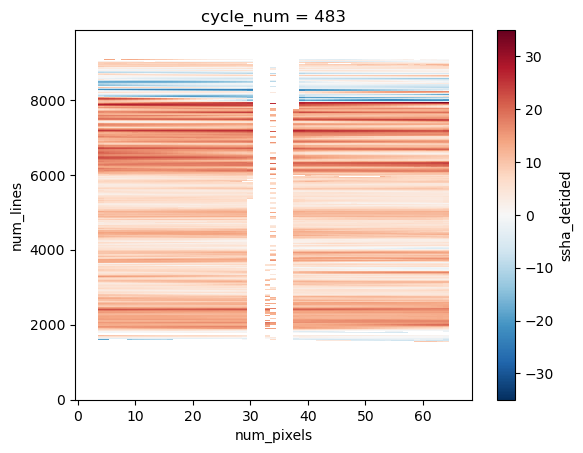

In [68]:
nd = 10
for ipass in range(1,29):
    # ds = xr.open_zarr(op.join(ddir,
    #                           "SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
    #                           % ipass)
    #                  ).interpolate_na("time", method="slinear", 
    #                                   fill_value="extrapolate",
    #                                   # use_coordinate=False,
    #                                   # max_gap=nd//2+1
    #                                  )
    ds = xr.open_zarr(op.join(ddir,
                              "SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                              % ipass)
                     )
    ds.ssha_detided.isel(cycle_num=9).plot(rasterized=True)
    plt.show()
    
    ssh = ds.ssha_detided.rolling(cycle_num=nd, min_periods=1).mean(skipna=True
                                       ).isel(cycle_num=slice(nd-1,None)
                                             ).chunk({"cycle_num":1,
                                                      "num_lines":-1,
                                                      "num_pixels":-1})
    ssh.isel(cycle_num=0).plot(rasterized=True)
    plt.show()
    if ipass == 1:
        print(ds, ssh)
        
    ssh.to_dataset(name="ssha_detided").to_zarr(op.join(ddir,
                        "SWOT_no_IT/10D_rolling/CalVal_pass%03d_v2.0.1.zarr"
                        % ipass),
                mode="w"
               )

In [71]:
te = xr.DataArray(np.arange(20), dims=["x"], 
                  coords={"x":np.arange(20)}
                 )
print(te.rolling(x=6).mean())
te_float = te.astype(float)
te_float[:4] = np.nan
print(te_float)
print(te_float.rolling(x=6).mean(skipna=True))
te_float.rolling(x=6, min_periods=1).mean(skipna=True)

<xarray.DataArray (x: 20)> Size: 160B
array([ nan,  nan,  nan,  nan,  nan,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,
        8.5,  9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5])
Coordinates:
  * x        (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
<xarray.DataArray (x: 20)> Size: 160B
array([nan, nan, nan, nan,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19.])
Coordinates:
  * x        (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
<xarray.DataArray (x: 20)> Size: 160B
array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  6.5,  7.5,
        8.5,  9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5])
Coordinates:
  * x        (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19


<xarray.DataArray (x: 20)> Size: 160B
array([ nan,  nan,  nan,  nan,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7.5,
        8.5,  9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5])
Coordinates:
  * x        (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19

In [67]:
ds = xr.open_zarr(op.join(ddir,
                          "SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                          % 1))
ssh = ds.ssha_detided.rolling(cycle_num=10, min_periods=1).mean(skipna=True
                                       ).isel(cycle_num=slice(nd-1,None)
                                             )
print(ssh.isel(cycle_num=0).sum().values)
print(ds.ssha_detided.isel(cycle_num=slice(None,10)).mean("cycle_num",skipna=True).sum().values)

2153250.2739477083
2153250.2739477083


In [66]:
# Check what's happening in the first few cycles
for i in range(5):
    window_valid = ds.ssha_detided.isel(cycle_num=slice(i, i+10)).count().values
    print(f"Window starting at cycle {i}: {window_valid} valid points total")
    
# Check the rolling result's first few values
rolling_result = ds.ssha_detided.rolling(cycle_num=10).mean(skipna=True)
print(rolling_result.isel(cycle_num=slice(0, 5)).values)  # Likely many NaNs

Window starting at cycle 0: 1061724 valid points total
Window starting at cycle 1: 1224108 valid points total
Window starting at cycle 2: 1225234 valid points total
Window starting at cycle 3: 1314752 valid points total
Window starting at cycle 4: 1479770 valid points total
[[[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan 

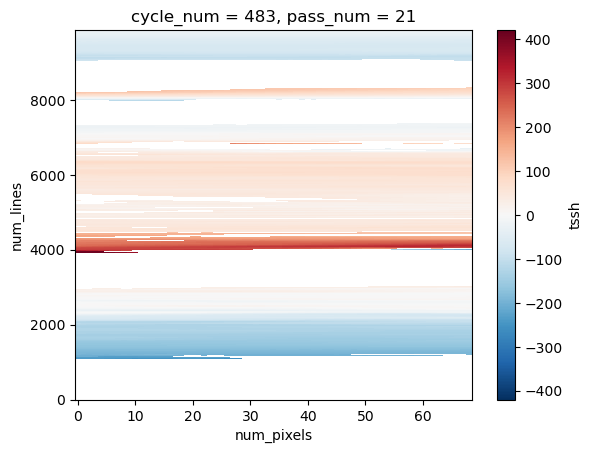

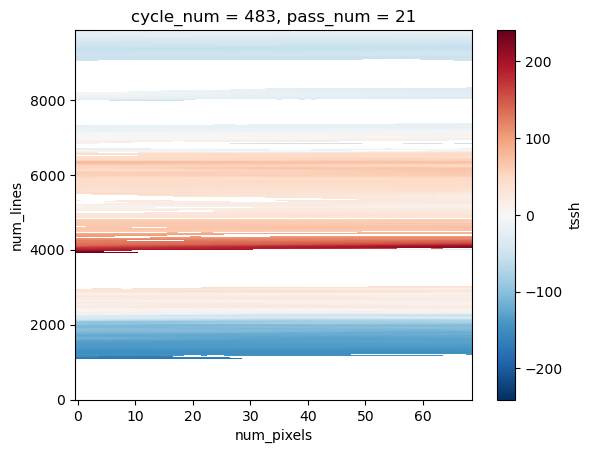

In [70]:
nd = 10
for ipass in range(21,22):

    ds = xr.open_dataset(op.join(ddir,
                              "tssh_swot1day/030_archs.tssh_swot1day_%03d.nc"
                              % ipass)
                        )
    ds.tssh.isel(cycle_num=9).plot(rasterized=True)
    plt.show()
    
    ssh = ds.tssh.rolling(cycle_num=nd, min_periods=1).mean(skipna=True
                                       ).isel(cycle_num=slice(nd-1,None)
                                             ).chunk({"cycle_num":1,
                                                      "num_lines":-1,
                                                      "num_pixels":-1})
    ssh.isel(cycle_num=0).plot(rasterized=True)
    plt.show()
    if ipass == 1:
        print(ds, ssh)
        
    ssh.to_dataset(name="total_ssh").to_zarr(op.join(ddir,
                    "tssh_swot1day/10D_rolling/030_archs_tssh_swot1day_%03d.zarr"
                    % ipass),
                                                mode="w"
                                               )

In [72]:
xr.open_dataset(op.join(ddir,
                              "tssh_swot1day/030_archs.tssh_swot1day_%03d.nc"
                              % 1)
                        )

<xarray.Dataset> Size: 572MB
Dimensions:     (cycle_num: 105, pass_num: 1, num_lines: 9860, num_pixels: 69)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * pass_num    (pass_num) int64 8B 1
  * num_lines   (num_lines) int64 79kB 0 1 2 3 4 5 ... 9855 9856 9857 9858 9859
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    tssh        (cycle_num, pass_num, num_lines, num_pixels) float64 571MB ...
Attributes:
    description:  Total SSH from HYCOM EXPT 3.0
    created_by:   B. Yadidya
    created_on:   Apr 24, 2026  07:42
    info:         /home1/ybadarva/swot_paper/nasahecc/reconstruct_tssh_swot1d...